## Main Quantitative Pipeline

tbd: deconvolution of the whole 3D image 

This pipieline is used for deconvolution: 

Steps: 
1. Deconvolution

2. Denoising 
3. Background correction

4. Segmentation
5. Quantification 

In [1]:
# imports
import h5py
from pathlib import Path
BASE_DIR = Path.cwd().parent
import stackview
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
from napari_simpleitk_image_processing import richardson_lucy_deconvolution # deconvolution
import numpy as np
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
# make binary image
import cv2 

from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))
# python files
import src.preprocessing as preproc


#### Specify Paths

In [2]:
full_image_path = Path(BASE_DIR/'data/corrected_images')

In [3]:
# load connexin image 
full_image = True # if False not Zero Padding happens

# image_path = 'seperate_planes/small_region/cnx_(300, 500, 1000).tiff' # small 3D region 
# plane = 54

# image_path = 'corrected_images/cnx43.tif' # full image

# image_path = 'seperate_planes/small_region/cnx_(237, 500, 1000).tiff' # latest test plane 16.04. 
cnx_img = io.imread(Path(full_image_path/'cnx43.tif')) #full image 
psf_path = 'PSF_488nm_cnx.h5'
psf_name = 'PSF_488'

# load cell image
# image_path = 'seperate_planes/small_region/trpn_(300, 500, 1000).tiff'
# image_path = 'corrected_images/cTnT.tif'
# psf_path = 'PSF_561nm_trop.h5'
# psf_name = 'PSF_561'

# load nuclei image
# image_path = 'seperate_planes/small_region/nuclei_(300, 500, 1000).tiff'
# image_path = 'corrected_images/cTnT.tif'
# psf_path = 'PSF_638nm_nuclei.h5'
# psf_name = 'PSF_638'

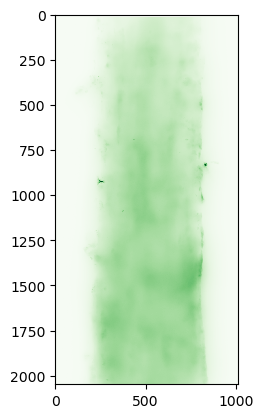

In [5]:
# show image 
stackview.imshow(cnx_img, axes = True, colormap="Greens")

### 1. Deconvolution

method: 
- use experimental PSF 

resource: 
https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/18a_deconvolution/introduction_deconvolution.html

#### load the PSF

In [4]:
psf_padded = io.imread(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"{psf_name}_padded.tiff"))

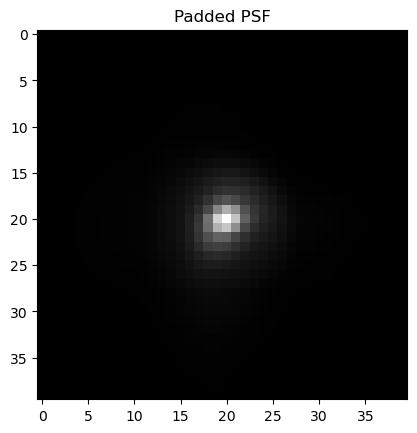

In [5]:
stackview.imshow(psf_padded, axes = True, colormap='gray', title="Padded PSF")

max value:  0.007673541
max value index:  75


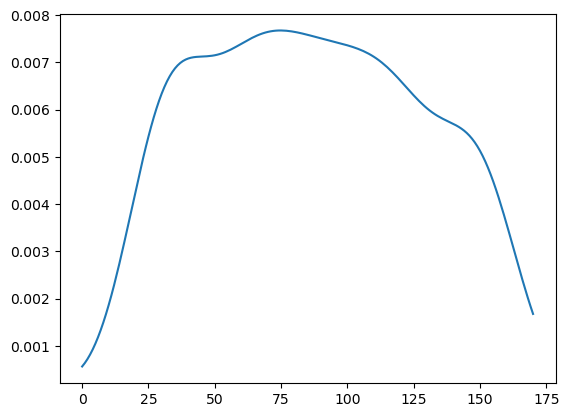

In [8]:
intensity_array = psf_padded.sum(axis=(1,2))
plt.plot(intensity_array)
max_value = max(psf_padded.sum(axis=(1,2)))
print("max value: ", max_value)
print("max value index: ", list(intensity_array).index(max_value))   # the centering shifted the center index only by 16 steps

#### Richardson-Lucy Deconvolution

In [ ]:
deconvolved = richardson_lucy_deconvolution(cnx_img, psf_padded[:], 8) # 5 iterations take 3 min

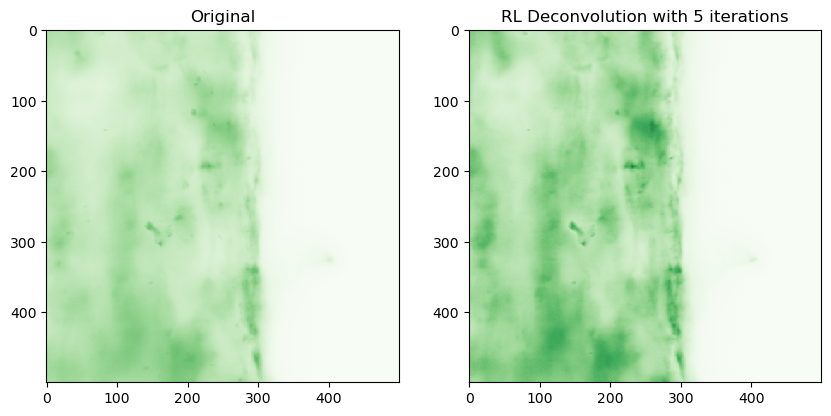

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10,10))
stackview.imshow(cnx_img, plot=axs[0], axes = True, colormap='Greens', title="Original", max_display_intensity=40000)
stackview.imshow(deconvolved, plot=axs[1], axes = True, colormap='Greens', title="RL Deconvolution with 8 iterations", max_display_intensity=40000)


### rolling ball background substraction

The size of connexin-43 plaques ranges between  $0.5 \mu m$ to $2.0 \mu m$ in diameter
- Rolling Ball: Calculation: If your resolution is $0.5 \mu m/pixel$, a radius of 5–6 pixels is a good starting point.
- Median Filter: Recommended size: A $3 \times 3$ or $5 \times 5$ pixel window.Anything larger will start to merge neighboring Connexin dots, making it look like one large, fake structure.

In [ ]:
# background substraction using rolling ball method
from skimage.restoration import rolling_ball 

In [ ]:
# compute the background using the rolling ball method and subtract it from the original image
background_rolling = rolling_ball(cnx_img, radius=10) #radius is the region looked at when determining what is background. It should be bigger than a connexin plaque so 30-50px 2.9 s per slide -> 290s per 100 slide = ca. 5 min for 100 slides
background_subtracted_rolling = cnx_img - background_rolling

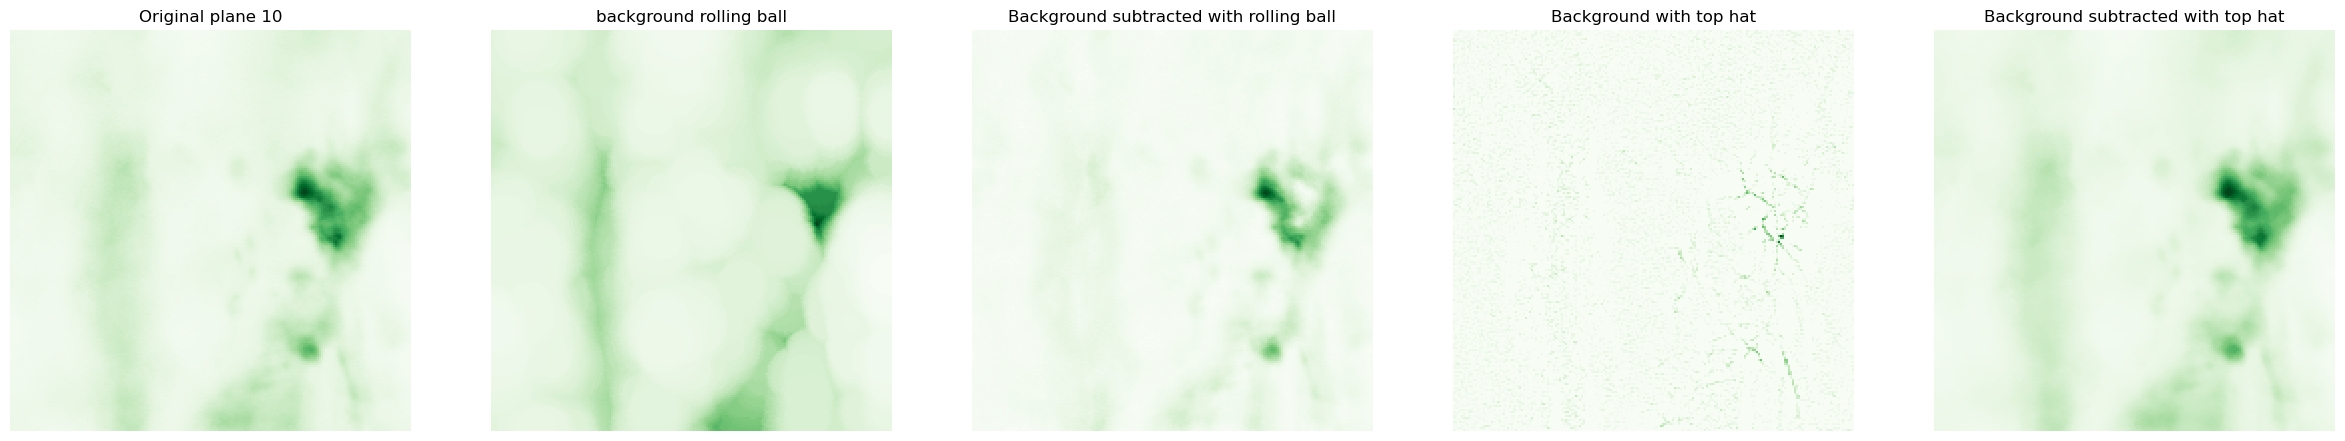

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(30,20))

stackview.imshow(cnx_img[10][200:400, :200], plot=axs[0], colormap="Greens",title = "Original plane 10")
stackview.imshow(background_rolling,plot = axs[1], title = "background rolling ball", colormap='Greens')

In [28]:
# apply rolling ball background subtraction to the whole image -> takes 17 s for radius of 10
# move over planes and apply rolling ball background subtraction to each plane
background_subtracted_rolling_full = np.zeros_like(cnx_img)
for i in range(cnx_img.shape[0]):
    background_rolling = rolling_ball(cnx_img[i], radius=7)
    background_subtracted_rolling_full[i] = cnx_img[i] - background_rolling

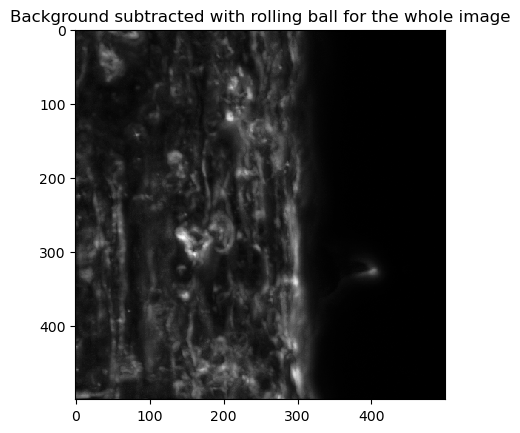

In [29]:
stackview.imshow(background_subtracted_rolling_full, axes = True, title="Background subtracted with rolling ball for the whole image")

In [36]:
# save the full background_subtracted_rolling_full image 
io.imsave(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7.tiff"), background_subtracted_rolling_full)

### Go here to load full background substracted image with rolling ball

In [37]:
background_subtracted_rolling_full = io.imread(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7.tiff"))

In [ ]:
deconvolved = richardson_lucy_deconvolution(background_subtracted_rolling_full, psf_padded[:], 8) # 1 min per iteration for the whole image, 5 iterations would be 5 min per image

In [42]:
# save the background substracted + deconvolved image
# io.imsave(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7_deconvolved_8iter.tiff"), deconvolved)

# load background substracted + deconvolved image
# deconvolved = io.imread(Path(BASE_DIR/'data'/'seperate_planes'/'small_region'/f"background_subtracted_rolling_full_radius7_deconvolved_8iter.tiff"))

huygens_image = io.imread(Path(BASE_DIR/'data'/f"test_plane_254.tiff"))

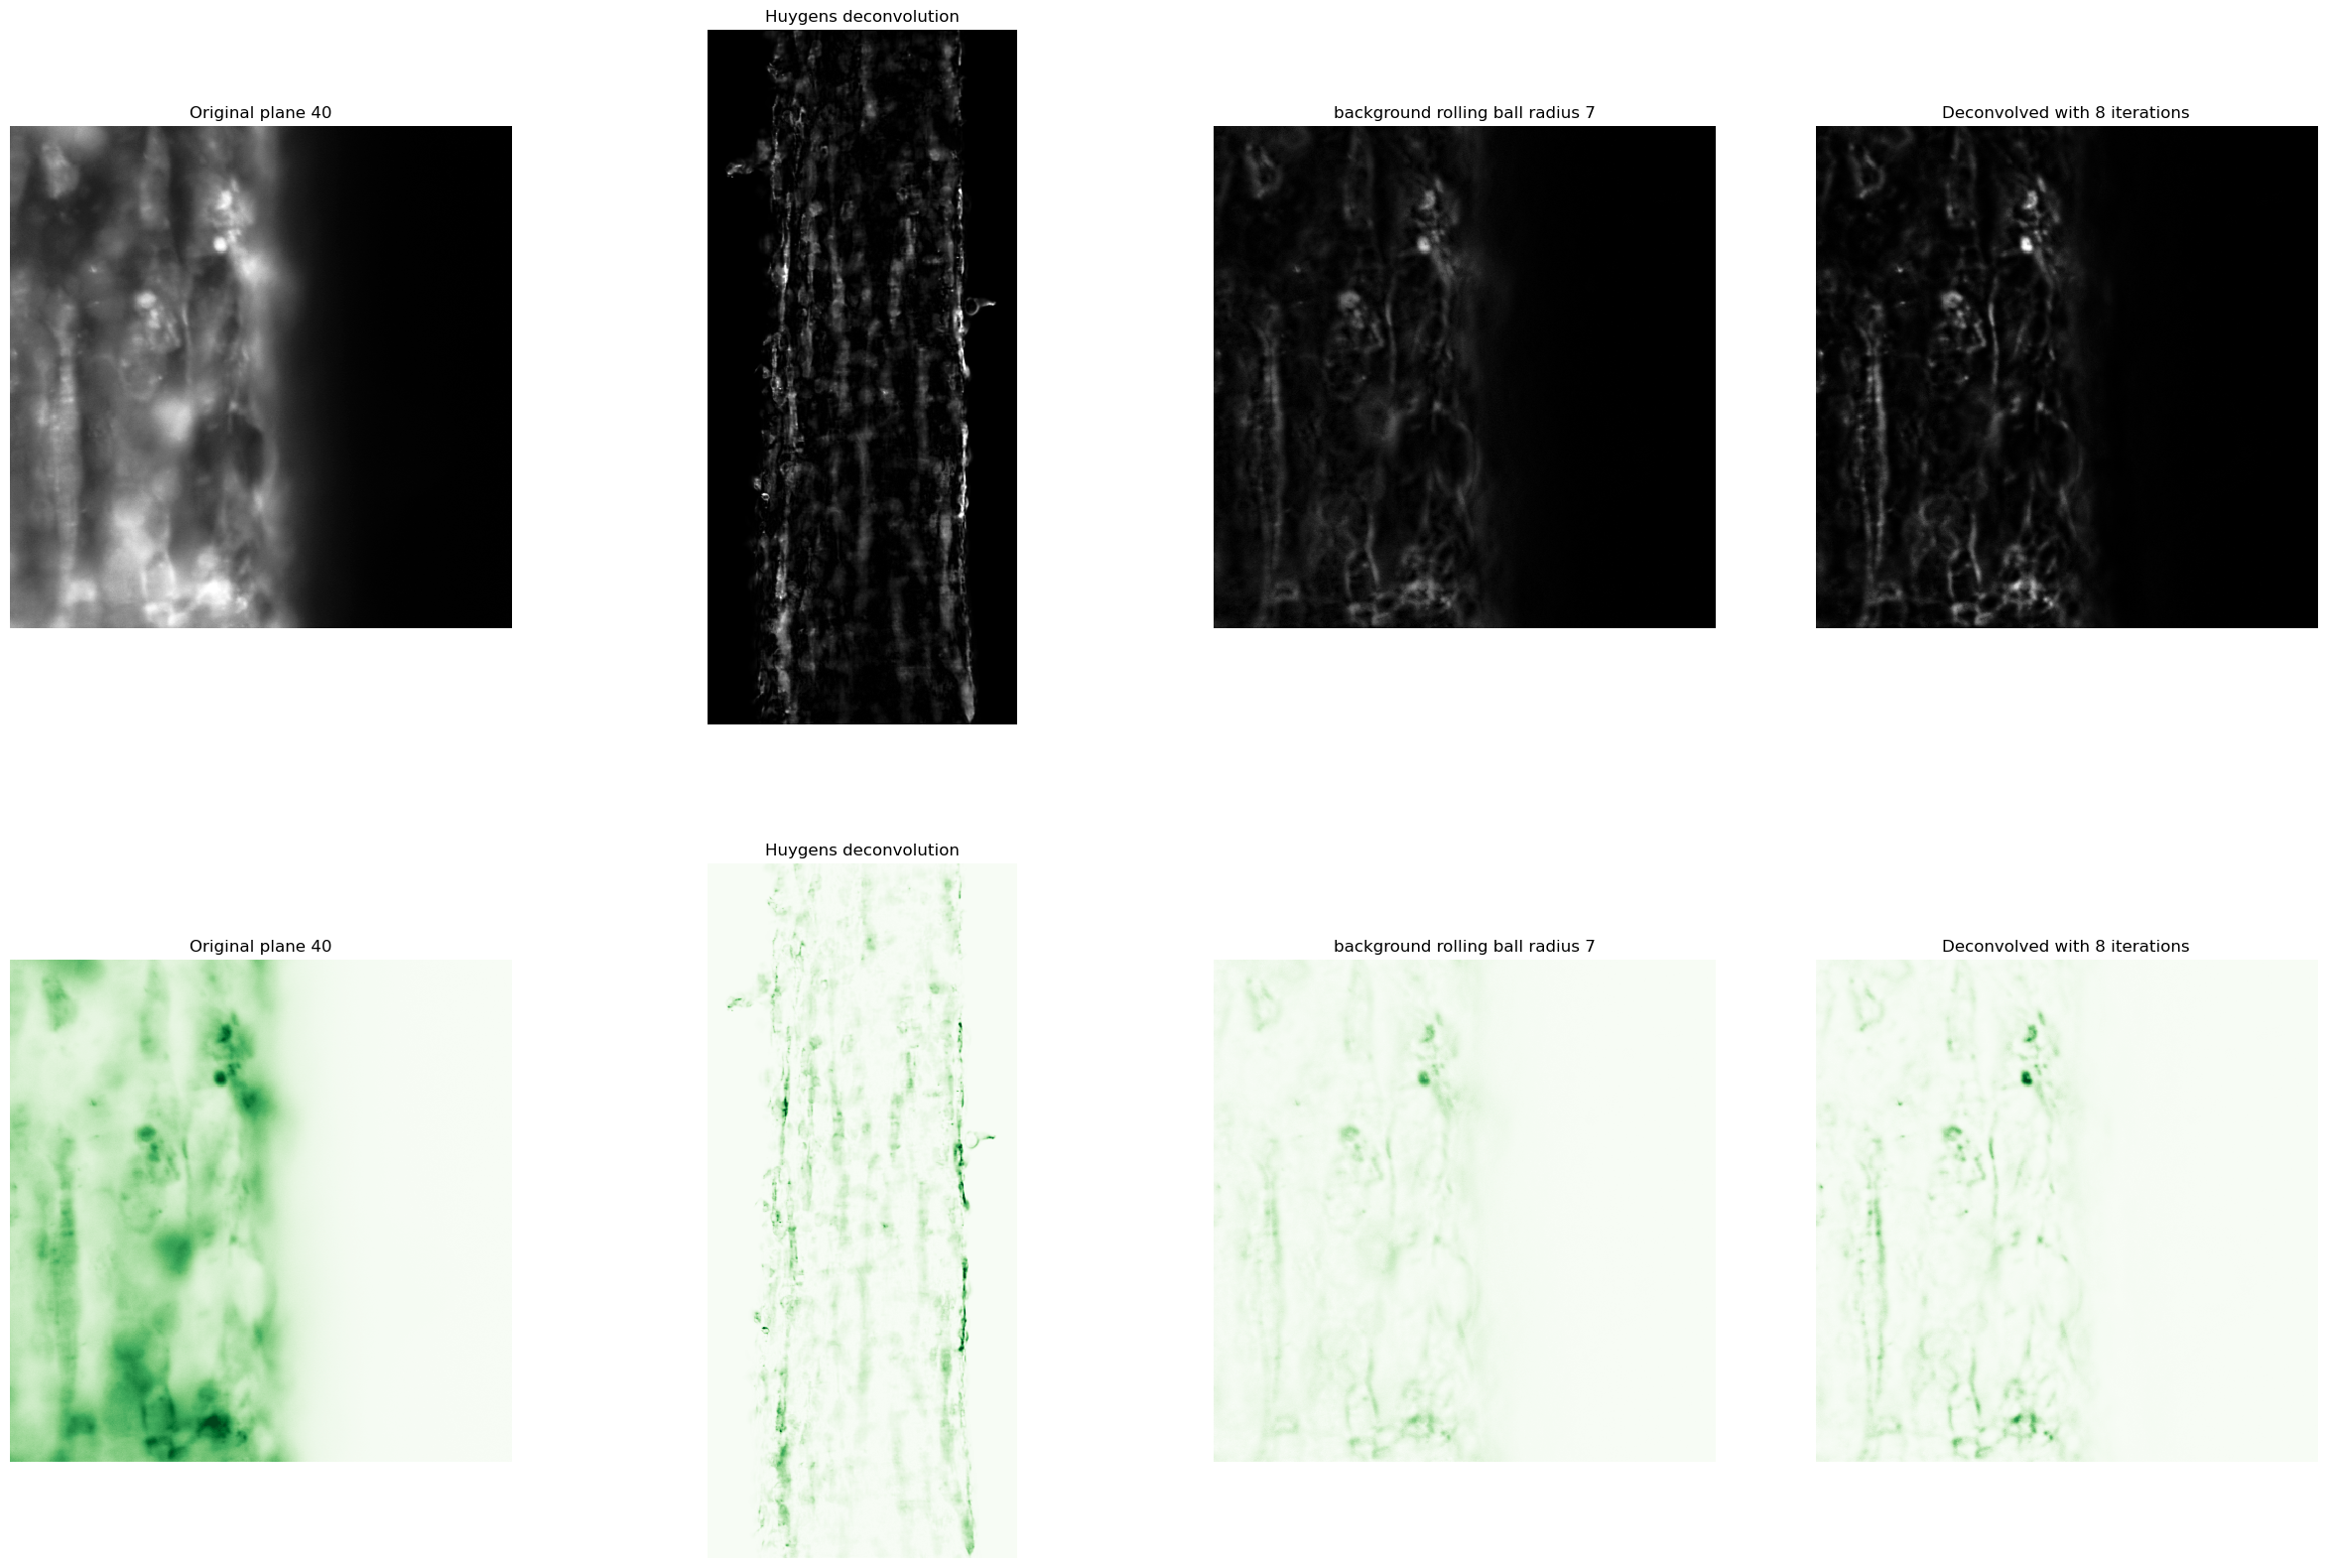

In [48]:
fig, axs = plt.subplots(2, 4, figsize=(30,20))
plane = 40
radius = 7
iterations = 8

stackview.imshow(cnx_img[plane], plot=axs[0, 0], title = "Original plane "f"{plane}", max_display_intensity=18000)
stackview.imshow(huygens_image, plot=axs[0, 1], title = "Huygens deconvolution", max_display_intensity=18000)
stackview.imshow(background_subtracted_rolling_full[plane],plot = axs[0, 2], title = f"background rolling ball radius {radius}", max_display_intensity=18000)
stackview.imshow(deconvolved[plane] , plot = axs[0, 3], title=f"Deconvolved with {iterations} iterations", max_display_intensity=18000)

stackview.imshow(cnx_img[plane], plot=axs[1, 0], title = "Original plane "f"{plane}", colormap="Greens", max_display_intensity=18000)
stackview.imshow(huygens_image, plot=axs[1, 1], title = "Huygens deconvolution", colormap="Greens", max_display_intensity=18000)
stackview.imshow(background_subtracted_rolling_full[plane],plot = axs[1, 2], title = f"background rolling ball radius {radius}",colormap="Greens", max_display_intensity=18000)
stackview.imshow(deconvolved[plane] , plot = axs[1, 3], title=f"Deconvolved with {iterations} iterations",colormap="Greens", max_display_intensity=18000)

Analysis: The images seem to lock worse after the deconvolution ? -> maybe also do the post processing step, Huygens Method and computational RL 

### Storing the deconvolved image 

In [ ]:
# apply PSF
number_of_iterations = 80
deconvolved = richardson_lucy_deconvolution(cnx_img, psf_padded, number_of_iterations)

In [ ]:
# # storing image after 40 iterations
# out_path = Path(BASE_DIR/'data/seperate_planes/small_region/cnx_254_(500, 1000)_deconvolved_80iterations.tiff')
# io.imsave(out_path, deconvolved) # save plane to folder 